# Introduction to Data Science – Lecture 12 – APIs
*COMP 5360 / MATH 4100, University of Utah, http://datasciencecourse.net/*

In this lecture we will explore how we can extract data from web-APIs. The first part of this tutorial is based on [this blog](https://www.dataquest.io/blog/python-api-tutorial/).

API stands for Application Programming Interface. It is supposed to be a **well-defined interface** for interacting with another program or library. 

For our case of extracting data via web-APIs, it is a well-defined interface for consuming data (in contrast to web-scraping), or, more generally, for the **interaction with a remote program** on a server. APIs aren't only generated so that you can read data; they're often designed so that you could write custom software to interact with the API. You could, for example, write your own reddit client.

APIs are usually well documented, as the organization that provides APIs wants you to use them. 

Here are a couple of examples of sites that have documented APIs:

 * [StackExchange](https://api.stackexchange.com/docs)  
 * ~~[Twitter](https://dev.twitter.com/rest/public)~~ (still documented, but now expensive)
 * [BlueSky](https://docs.bsky.app/)
 * [Facebook](https://developers.facebook.com/docs/graph-api)
 * [KEGG](http://www.genome.jp/kegg/rest/keggapi.html) 
 * [Reddit](https://www.reddit.com/dev/api/)
 * [Google Maps](https://developers.google.com/maps/) 
 * and many many more. 
 
Some folks compile lists of [available free APIs](https://github.com/public-apis/public-apis).
 
Most APIs require some form of authentication and have rules on what you're allowed to do and what not. Follow those rules, or you will be blocked faster than you can say `GET`. 
 
Working with an API is a lot like working with a website, but instead of a human in front of the screen, it's computers talking to each other. 

#### REST

We'll be using the dominant form of APIs on the web: REST (REpresentational State Transfer). REST APIs use an [URI](https://en.wikipedia.org/wiki/Uniform_Resource_Identifier) (a Uniform Resource Identifier; URLs are one specific form of URIs) to specify what you want to do with and API.

All API methods in REST are relative to a base URL. E.g., for [useless facts](https://uselessfacts.jsph.pl/) this would be
```
https://uselessfacts.jsph.pl/
```

A query for today's useless fact would look like this: 

```
https://uselessfacts.jsph.pl/api/v2/facts/today
```

and a query for a random useless fact in german would look like this:

```
https://uselessfacts.jsph.pl/api/v2/facts/random?language=de
```

*(Note, course staff does not vouch for the veracity of these facts!)*


#### Format
REST APIs can return data in different forms. The most common ones are JSON and XML, and of those two, JSON is now dominant. 

JSON stands for JavaScript Object Notation, and is a pretty convenient format, as we'll see. 
 

#### Live Example

Let's start with a very simple example, retrieving the current position of the International Space Station (ISS). We will be using the [requests library](https://requests.readthedocs.io/en/latest/), which will handle our communication with the server.

In [1]:
import requests 
# Make a get request to get the latest position of the international space station from the opennotify api.
response = requests.get("http://api.open-notify.org/iss-now.json")

response

<Response [200]>

That looks good, we've received a response with the message "200". What does the 200 mean? It's a status code - you've probably seen a different status code, the "Error 404" on the internet. 

Here are a couple of codes:

 * **200** – everything went okay, and the result has been returned (if any)
 * **301** – the server is redirecting you to a different endpoint. This can happen when a company switches domain names, or an endpoint name is changed.
 * **401** – the server thinks you’re not authenticated. This happens when you don’t send the right credentials to access an API (we’ll talk about authentication later).
 * **400** – the server thinks you made a bad request. This can happen when you don’t send along the right data, among other things.
 * **403** – the resource you’re trying to access is forbidden – you don’t have the right permissions to see it.
 * **404** – the resource you tried to access wasn’t found on the server.

Let's try to get a response with a wrong URL:

In [2]:
response_failed = requests.get("http://api.open-notify.org/iss")

response_failed

<Response [404]>

We used the get methods to put in a GET request. There are four different types of requests: 

![Request types](requests.png)
[Source](https://en.wikipedia.org/wiki/Representational_state_transfer)

Let's look at the payload of our previous, successful response:

In [3]:
response.content

b'{"timestamp": 1770940330, "message": "success", "iss_position": {"latitude": "26.5655", "longitude": "76.6874"}}'

We can already see that this is JSON (though it is stored a `bytes` object), but we can check formally:

In [4]:
response.headers['content-type']

'application/json'

We can decode this byte object, then the JSON will be readable. 

In [5]:
response_j = response.content.decode("utf-8")
print(response_j)

{"timestamp": 1770940330, "message": "success", "iss_position": {"latitude": "26.5655", "longitude": "76.6874"}}


Let's take a look at the JSON format with nice formatting here:

```JSON
{
  "timestamp": 1475240215,
  "message": "success", 
  "iss_position": {
    "latitude": -30.005751854107206, 
    "longitude": -104.20085371352678
  } 
}
```
The latitude and longitude numbers should be different however because ISS keeps moving while this is a static markdown cell that was written when ISS was in a different place.

This JSON response looks a lot like a dictionary (or objects, for that matter)! We have key-value pairs. 

We can use the [json library](https://docs.python.org/3/library/json.html) to convert JSON into objects:

In [6]:
import json
response_d = json.loads(response_j)

# Now we can see it is indeed a dict!
print(type(response_d))

# It still prints like a dict
print(response_d)

# And we can access it like one
response_d["iss_position"]

<class 'dict'>
{'timestamp': 1770940330, 'message': 'success', 'iss_position': {'latitude': '26.5655', 'longitude': '76.6874'}}


{'latitude': '26.5655', 'longitude': '76.6874'}

Or, not surprisingly, pandas can also load a json object:

In [7]:
import pandas as pd 
from io import StringIO

df = pd.read_json(StringIO(response_j))
df

,timestamp,message,iss_position
latitude,2026-02-12 23:52:10,success,26.5655
longitude,2026-02-12 23:52:10,success,76.6874


This isn't quite what we want - we probably want one row per timestamp and longitude and latitude as columns:

In [8]:
def flatten(response_d):
    response_flat = {}
    response_flat["latitude"] = response_d["iss_position"]["latitude"]
    response_flat["longitude"] = response_d["iss_position"]["longitude"]
    response_flat["timestamp"] = response_d["timestamp"]
    return response_flat
flatten(response_d)

{'latitude': '26.5655', 'longitude': '76.6874', 'timestamp': 1770940330}

That looks better. Let's get a couple of positions of the ISS over time and save it as an array:

In [9]:
import time

def pull_position():
    """Retreives the position of the ISS and returns it as a flat dictionary"""
    response = requests.get("http://api.open-notify.org/iss-now.json")
    response_j = response.content.decode("utf-8")
    response_d = json.loads(response_j)
    flat_response = flatten(response_d)
    return flat_response    

iss_position = []
    
# calls pull_position 10 times with 3 seconds break
for i in range(10):
    flat_response = pull_position()
    iss_position.append(flat_response)
    print(flat_response)
    time.sleep(3)
    
len(iss_position)

{'latitude': '36.2234', 'longitude': '87.9000', 'timestamp': 1770940548}
{'latitude': '36.4920', 'longitude': '88.2762', 'timestamp': 1770940555}
{'latitude': '36.7386', 'longitude': '88.6260', 'timestamp': 1770940561}
{'latitude': '37.1674', 'longitude': '89.2440', 'timestamp': 1770940571}
{'latitude': '37.2892', 'longitude': '89.4219', 'timestamp': 1770940574}
{'latitude': '37.4108', 'longitude': '89.6005', 'timestamp': 1770940577}
{'latitude': '37.6730', 'longitude': '89.9895', 'timestamp': 1770940584}
{'latitude': '37.7936', 'longitude': '90.1700', 'timestamp': 1770940587}
{'latitude': '37.9137', 'longitude': '90.3511', 'timestamp': 1770940590}
{'latitude': '38.0536', 'longitude': '90.5633', 'timestamp': 1770940593}


10

Now we can convert this into a nice dataframe:

In [10]:
iss_position_df = pd.DataFrame(iss_position)
iss_position_df['timestamp']  = pd.to_datetime(iss_position_df['timestamp'], unit="s")

iss_position_df = iss_position_df.set_index(pd.DatetimeIndex(iss_position_df['timestamp']))
iss_position_df["latitude"] = iss_position_df["latitude"].map(float)
iss_position_df["longitude"] = iss_position_df["longitude"].map(float)
iss_position_df

,latitude,longitude,timestamp
timestamp,,,
2026-02-12 23:55:48,36.2234,87.9000,2026-02-12 23:55:48
2026-02-12 23:55:55,36.4920,88.2762,2026-02-12 23:55:55
2026-02-12 23:56:01,36.7386,88.6260,2026-02-12 23:56:01
2026-02-12 23:56:11,37.1674,89.2440,2026-02-12 23:56:11
2026-02-12 23:56:14,37.2892,89.4219,2026-02-12 23:56:14
2026-02-12 23:56:17,37.4108,89.6005,2026-02-12 23:56:17
2026-02-12 23:56:24,37.6730,89.9895,2026-02-12 23:56:24
2026-02-12 23:56:27,37.7936,90.1700,2026-02-12 23:56:27
2026-02-12 23:56:30,37.9137,90.3511,2026-02-12 23:56:30


Let's see how the ISS moves

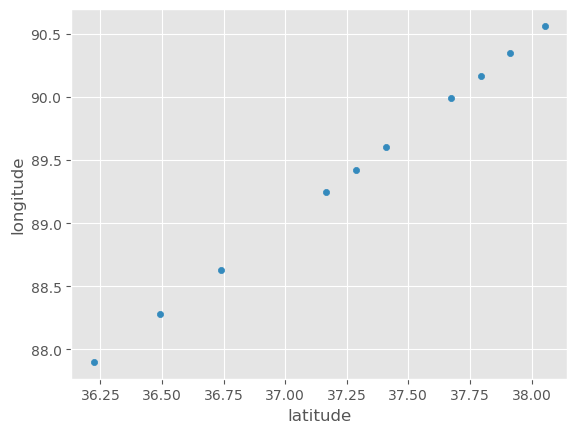

In [11]:
import matplotlib.pyplot as plt
# This next line tells jupyter to render the images inline
%matplotlib inline
plt.style.use('ggplot')
iss_position_df.plot(kind="scatter", x="latitude", y="longitude")
plt.show()

## API Example 2: PokeAPI

Open Notify has removed some of their API features. So let's use another public API to demonstrate queries: [PokeAPI](https://pokeapi.co/):

![PokeAPI Screenshot](pokeapiscreenshot.png)

Notice how this one boasts several endpoints (`pokemon`, `ability`, `type`, etc) for different kinds of queries.

Let's start with with the `pokemon` endpoint to get data for specific pokemon. We can look at the documentation and see that it returns a pretty large JSON object. Scanning through, I see there's a keyword `game_indices` which has members beneath it for the `game_index` and `version`>`name`. I'll print out all of those.

![PokeAPI Screenshot](pokemonendpoint.png)

##### Follow along and/or try it with your own favorite pokemon!

Are game indices interesting to you? Check out what else is available. For example, the image above shows `abilities`, can you try printing them out for your pokemon?

In [ ]:
bulbresponse = requests.get("http://pokeapi.co/api/v2/pokemon/bulbasaur")

# Check to make sure it worked
if bulbresponse.status_code == 200:
    
    # Convert to JSON and loop through to see the index and versions
    bulbj = json.loads(bulbresponse.content)
    for game in bulbj["game_indices"]:
        print(f'#{game["game_index"]} in {game["version"]["name"]}')
        
# If the status code is something else, check it
else:
    print(bulbresponse)

What if we want several Pokemon? This API provides us a way to index the results with the keywords `limit` and `offset`. We use the `?` to indicate we are passing parameters and the ampersand `&` to glue the parameters together.

In [ ]:
response5 = requests.get("http://pokeapi.co/api/v2/location?limit=10&offset=5")

# Check to make sure it worked
if response5.status_code == 200:
    
    # Convert to JSON and loop through to see the name and URL
    j5 = json.loads(response5.content)
    for place in j5["results"]:
        print(place["name"], '\t', place["url"])
        
# If the status code is something else, check it
else:
    print(response5)

For this API, there are end points for most indices and names, so `limit` and `offset` are really there to provide a mechanism to do pagination of the results. In other APIs, this method may be the most expedient way to provide parameters for queries.

Another thing to note is that the PokeAPI policies **require caching** so they don't have to serve up large quantities of data repeatedly to the same client. There are several libraries, [such as this one](https://github.com/PokeAPI/pokebase) that can handle this for you for this particular API. If you use an API in your project, please make sure you are following the API's policies. ***If you use an API in your project, you will be expected to have a discussion of their policies and how you are following them.***

## API Example 3: Nationalize.io

Let's see one more example of using parameters from [nationalize.io](https://nationalize.io/) which purportedly predicts nationality based on last name. ***We don't vouch for it—we're just using it as a free API with a parameter.*** Note that it is limited to 100 requests/day without an API key.

In [ ]:
response = requests.get("https://api.nationalize.io/?name=alberts")

# Check to make sure it worked
if response.status_code == 200:
    
    # Print a list of country guesses and their proability
    responsej = json.loads(response.content)
    for country in responsej['country']:
        print(f'{country["country_id"]}, probability:{country["probability"]}')
        
# If the status code is something else, check it
else:
    print(response)

## API Example 4 (API Key example): OpenWeather 

#### API key? What's that?

Several providers use an identifier to distinguish applications (or individuals), apply limits, or charge for services. Even those that are free may use API keys to prevent abuse or to prepare to upsell you to a more wide or permissive plan.

Note that a provider may not generate an API key immediately. It can often require some lead time. ***Therefore, if you plan to use a service that requires some form of authorization/authentication for your project, please note in your proposal whether you already have such capability.***

Let's see an example of an API key as used in [OpenWeather](https://openweathermap.org/api). Note this service has a free plan, but also *several* paid plans. We're specifically using the free API described [here](https://openweathermap.org/current).

I have hidden my API_KEY in a file `credentials.py` so I can import the variable without sharing it with you :)

In [ ]:
# Read my API Key into a variable
from credentials_kate import API_KEY

# OpenWeather just has me send the API Key as the APPID parameter in my request:
response = requests.get(f'https://api.openweathermap.org/data/2.5/weather?lat=40.76&lon=-111.89&APPID={API_KEY}')
if response.status_code == 200:
    
    # Print the response
    responsej = json.loads(response.content)
    print(responsej)
        
# If the status code is something else, check it
else:
    print(response)

Scrolling through the [documentation](https://openweathermap.org/current), we can also query by city name with `q` or zip code with `zip`:

In [ ]:
# OpenWeather just has me send the API Key as the APPID parameter in my request:
response = requests.get(f'https://api.openweathermap.org/data/2.5/weather?zip=91106&APPID={API_KEY}')
if response.status_code == 200:
    
    # Print the response
    responsej = json.loads(response.content)
    print(responsej)
        
# If the status code is something else, check it
else:
    print(response)